## 1. Set up

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('tab10')

# Reproducibility
np.random.seed(42)

print('Libraries loaded')

Libraries loaded


## 2. Load price data

In [2]:
prices = pd.read_csv('../data/prices.csv')
prices['time'] = pd.to_datetime(prices['time'])
prices = prices.set_index('time')

print(f'Shape: {prices.shape}')
print(f'Date range: {prices.index.min().date()} → {prices.index.max().date()}')
print(f'Tickers: {prices.columns.tolist()}')
prices.head()

Shape: (871, 8)
Date range: 2021-11-01 → 2025-04-29
Tickers: ['VNM', 'VIC', 'VHM', 'FPT', 'HPG', 'MWG', 'VCB', 'MBB']


,VNM,VIC,VHM,FPT,HPG,MWG,VCB,MBB
time,,,,,,,,
2021-11-01,70.51,47.90,81.91,48.63,31.36,62.56,42.23,12.82
2021-11-02,69.88,47.90,82.59,48.78,31.25,62.03,42.62,12.82
2021-11-03,69.10,47.65,80.55,48.78,31.30,61.98,42.97,13.16
2021-11-04,69.26,47.50,80.35,48.73,31.70,62.51,42.84,13.05
2021-11-05,69.88,47.50,79.67,49.54,31.87,63.52,42.44,12.93


## 3. Price trends

Raw prices live on very different scales (e.g. FPT ~100k VND vs MBB ~13k VND), which makes a single chart hard to read. We plot both:

- **Raw prices** for absolute reference.
- **Normalized prices** (each series rebased to 100 on day 1) to compare growth on the same scale.

Normalizing matters because what we care about is *percentage change*, not absolute price. A stock going from 100 to 110 (+10%) is equivalent to one going from 10 to 11 (+10%) — but the raw chart would make the first look like a much "bigger" move.

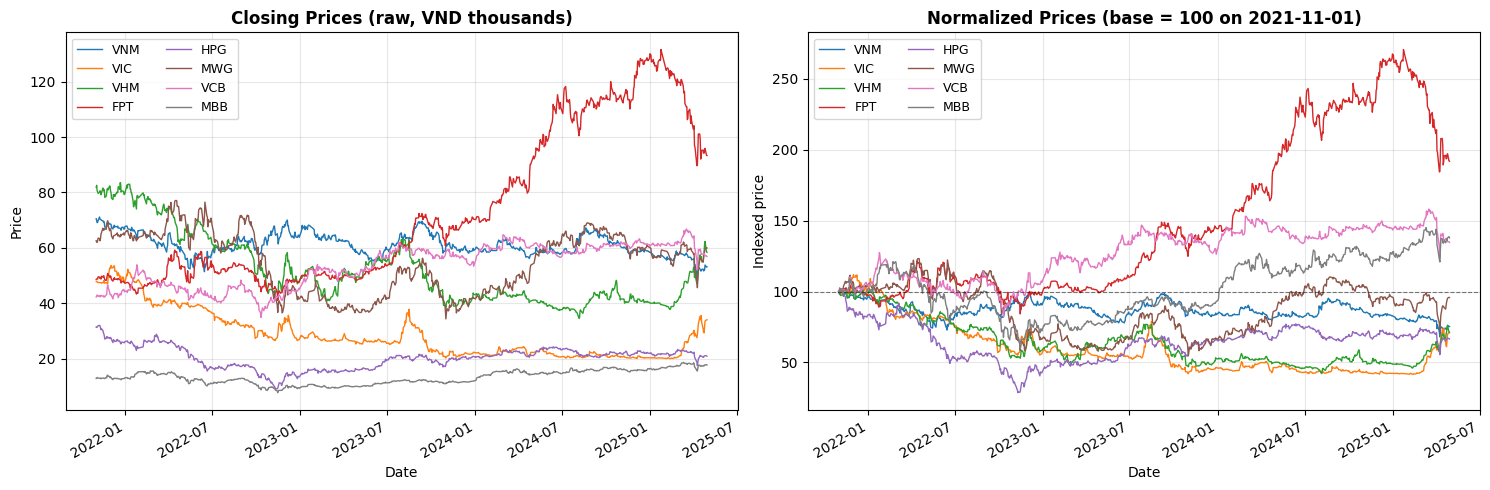

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Raw prices
prices.plot(ax=axes[0], linewidth=1.0)
axes[0].set_title('Closing Prices (raw, VND thousands)', fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price')
axes[0].legend(ncol=2, fontsize=9)

# Normalized to 100
normalized = prices.div(prices.iloc[0]).mul(100)
normalized.plot(ax=axes[1], linewidth=1.0)
axes[1].set_title('Normalized Prices (base = 100 on 2021-11-01)', fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Indexed price')
axes[1].axhline(100, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1].legend(ncol=2, fontsize=9)

plt.tight_layout()
plt.show()

**Observations on the normalized chart:**
- **FPT** is clearly the strongest performer over the period (well above the base line of 100).
- **VCB** and **MBB** (banks) also show positive cumulative growth.
- **VIC, VHM, HPG, VNM** all finish well below 100 - real estate and steel suffered during this window.**Observations on the normalized chart:**

## 4. Daily returns

For risk and portfolio analysis we work with **simple daily returns**:

$$r_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1$$

The first row becomes `NaN` (no previous price) and is dropped, leaving 870 trading days.

**Why simple returns instead of log returns?** Simple returns are additive across assets — for a portfolio with weights $w$, the portfolio return is $r_p = \sum_i w_i r_i$. This property is essential for portfolio optimization, so we use simple returns throughout this project.

In [4]:
returns = prices.pct_change().dropna()
print(f'Returns shape: {returns.shape}')
returns.head().round(4)

Returns shape: (870, 8)


,VNM,VIC,VHM,FPT,HPG,MWG,VCB,MBB
time,,,,,,,,
2021-11-02,-0.0089,0.0000,0.0083,0.0031,-0.0035,-0.0085,0.0092,0.0000
2021-11-03,-0.0112,-0.0052,-0.0247,0.0000,0.0016,-0.0008,0.0082,0.0265
2021-11-04,0.0023,-0.0031,-0.0025,-0.0010,0.0128,0.0086,-0.0030,-0.0084
2021-11-05,0.0090,0.0000,-0.0085,0.0166,0.0054,0.0162,-0.0093,-0.0092
2021-11-08,0.0180,-0.0011,0.0049,-0.0020,0.0035,-0.0030,0.0073,-0.0054


### 5.1 Return distributions

Looking at the histogram of daily returns gives us a first sense of each stock's volatility profile. We expect distributions centered near zero (daily mean is tiny) with most returns falling within ±2-3%, plus some extreme observations in the tails.

The red dashed line marks the mean of each distribution.

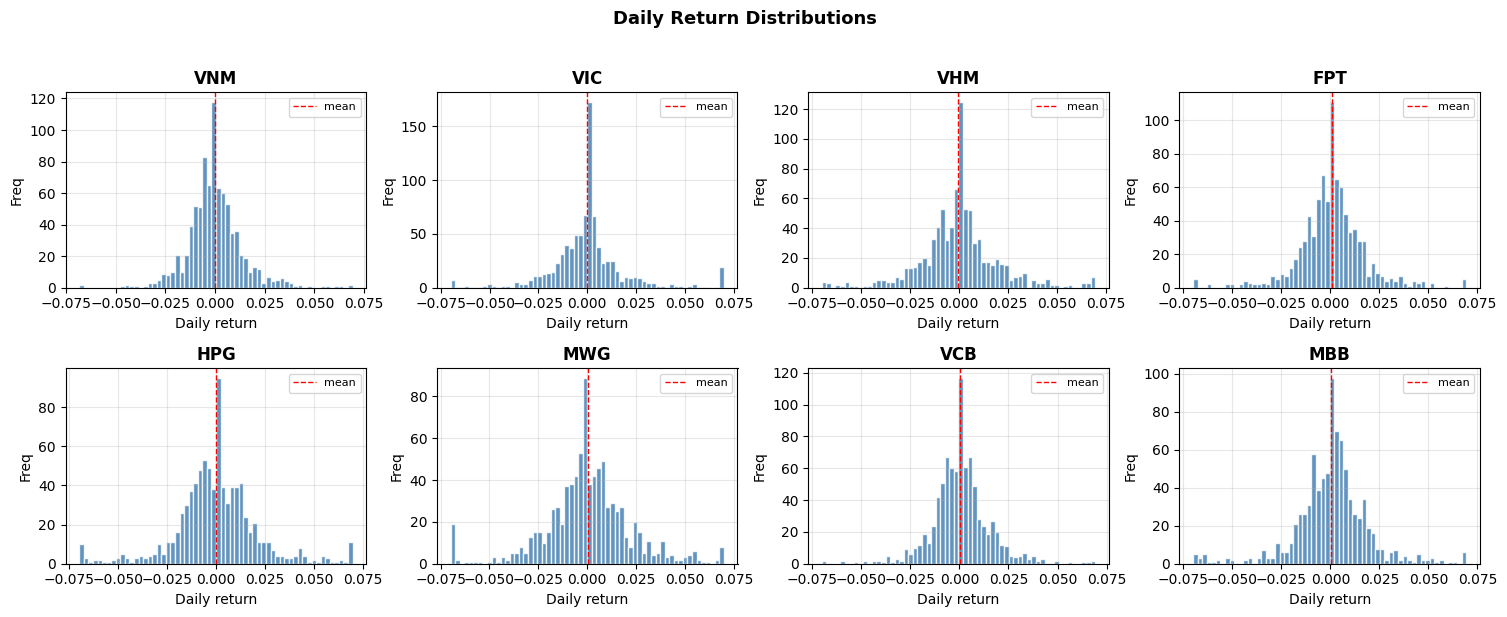

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, col in zip(axes.flat, returns.columns):
    ax.hist(returns[col], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(returns[col].mean(), color='red', linestyle='--', linewidth=1, label='mean')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Daily return')
    ax.set_ylabel('Freq')
    ax.legend(fontsize=8)
plt.suptitle('Daily Return Distributions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Return statistics

The first four moments of each distribution tell us about the **shape** of the return distribution:

- **Mean**: expected daily return (always tiny for daily data).
- **Std**: daily volatility, the standard measure of risk.
- **Skewness**: asymmetry. Negative skew means the left tail (losses) is longer.
- **Excess kurtosis**: "tailedness" beyond Gaussian. Values > 0 indicate **fat tails**: extreme moves happen more often than a normal distribution would predict.

In [6]:
stats = pd.DataFrame({
    'mean_daily_%': returns.mean() * 100,
    'std_daily_%':  returns.std()  * 100,
    'skew':         returns.skew(),
    'kurtosis':     returns.kurtosis(),
    'min_%':        returns.min() * 100,
    'max_%':        returns.max() * 100,
}).round(3)
stats

,mean_daily_%,std_daily_%,skew,kurtosis,min_%,max_%
VNM,-0.023,1.402,0.547,4.075,-6.837,6.921
VIC,-0.019,2.003,0.493,3.971,-7.000,6.997
VHM,-0.019,1.997,0.173,2.528,-6.986,6.961
FPT,0.090,1.708,-0.040,3.593,-7.000,6.975
HPG,-0.023,2.181,0.043,2.242,-6.996,6.972
MWG,0.021,2.271,-0.166,1.883,-6.989,6.999
VCB,0.046,1.510,0.119,3.618,-7.000,6.909
MBB,0.055,1.896,-0.252,3.337,-7.002,6.937


**Key observations:**

- Daily means are very small (basis-point scale), typical for daily equity data. Annualized differences will be much more visible.
- All series show **excess kurtosis > 0** (fat tails), large moves happen more often than a Gaussian distribution would predict. This is well-documented in financial returns and is the reason mean-variance optimization (which assumes Gaussian) can underestimate tail risk.
- Min/max columns show single-day moves of −5% to +6–7%, close to the HOSE daily price limit (±7%).

## 6. Annualized risk and return

To make daily statistics comparable to benchmarks (interest rates, market indices), we annualize daily statistics:

$$\mu_{\text{ann}} = \mu_{\text{daily}} \times N, \qquad \sigma_{\text{ann}} = \sigma_{\text{daily}} \times \sqrt{N}$$

where $N$ is the number of trading days per year.

**Choice of $N$:** While the international convention is $N = 252$, this is calibrated to US markets. We verified empirically from our dataset:

| Year | Trading days on HOSE |
|------|---------------------|
| 2022 | 249 |
| 2023 | 249 |
| 2024 | 250 |

HOSE has slightly fewer trading days than US markets because of additional Vietnamese public holidays (Lunar New Year, Reunification Day, etc.). We therefore use **$N = 250$** for this Vietnamese-market analysis.

The asymmetry - mean scales linearly with $N$ but volatility scales with $\sqrt{N}$ - assumes daily returns are approximately independent. This is the mathematical foundation for why long-horizon investments tend to have better risk-adjusted profiles.

The **Sharpe ratio** measures excess return per unit of risk:

$$\text{Sharpe} = \frac{\mu_{\text{ann}} - r_f}{\sigma_{\text{ann}}}$$

For this exploratory analysis we set $r_f = 0$ for simplicity. A realistic Vietnamese risk-free rate (~3–5%, 10-year government bond yield) will be used in the optimization notebook.

In [8]:
# Annualization factor: HOSE has ~250 trading days/year
# (verified empirically from our 2022-2024 full-year data: 249, 249, 250)
TRADING_DAYS = 250

ann = pd.DataFrame({
    'ann_return_%':     returns.mean() * TRADING_DAYS * 100,
    'ann_volatility_%': returns.std()  * np.sqrt(TRADING_DAYS) * 100,
})
ann['sharpe_rf0'] = ann['ann_return_%'] / ann['ann_volatility_%']
ann = ann.round(3).sort_values('sharpe_rf0', ascending=False)
ann

,ann_return_%,ann_volatility_%,sharpe_rf0
FPT,22.389,27.003,0.829
VCB,11.407,23.870,0.478
MBB,13.745,29.986,0.458
MWG,5.235,35.915,0.146
VHM,-4.748,31.569,-0.150
VIC,-4.866,31.664,-0.154
HPG,-5.756,34.483,-0.167
VNM,-5.682,22.169,-0.256


## 7. Correlation and covariance matrices

These two matrices are the central linear-algebra objects of the project:

- **Correlation matrix** is dimensionless with values in $[-1, 1]$ - used for visualization and intuition.
- **Covariance matrix** $\Sigma$ has units of (return)² and is what enters the portfolio risk formula $w^\top \Sigma\, w$. It is also the matrix we will diagonalize in the PCA notebook.

**Why we need both:** two stock pairs can have the same correlation (e.g. 0.5) but very different covariances if one pair has much higher volatility. The optimizer needs the actual covariance - correlation alone is not enough.

For visualization, we scale the covariance matrix by $10^4$ so the annotations are readable (raw daily covariances are tiny numbers like 0.00018).

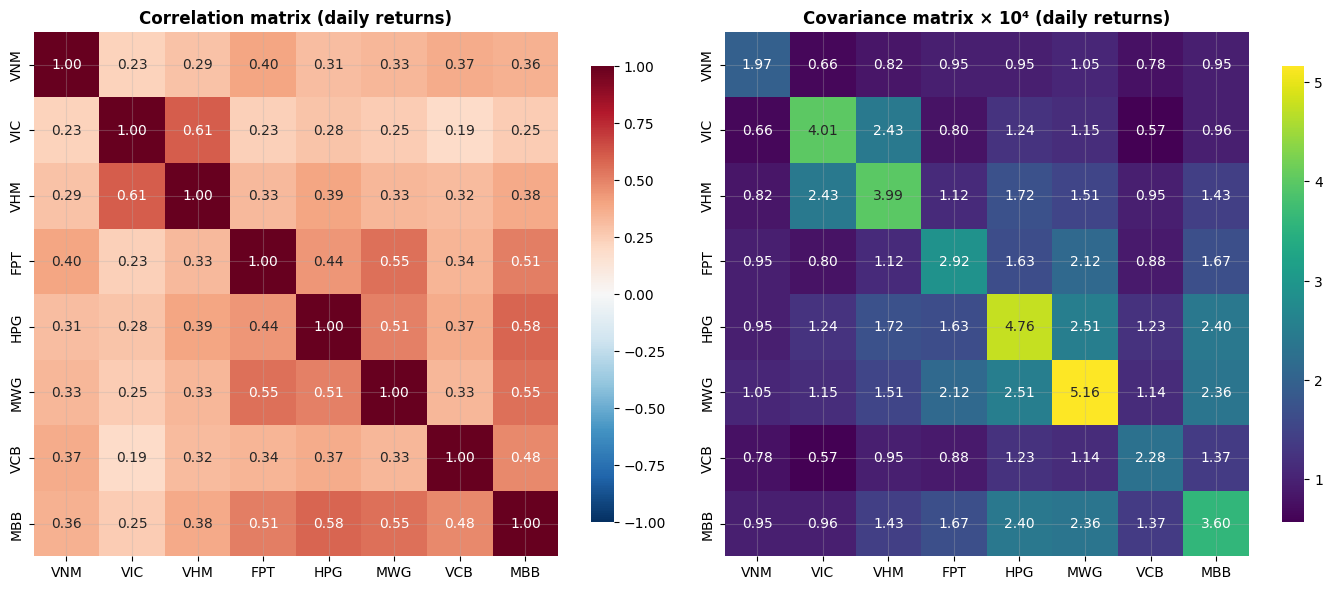

In [9]:
corr = returns.corr()
cov  = returns.cov()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Correlation matrix (daily returns)', fontweight='bold')

# Scale covariance by 10^4 to make annotations readable
sns.heatmap(cov * 1e4, annot=True, fmt='.2f', cmap='viridis',
            square=True, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Covariance matrix × 10⁴ (daily returns)', fontweight='bold')

plt.tight_layout()
plt.show()

**Reading the correlation matrix:**

- **VIC–VHM = 0.61** - highest pair, both belong to the Vingroup conglomerate (Vinhomes is the real-estate arm of Vingroup).
- **HPG–MBB ≈ 0.58** and **FPT–MWG ≈ 0.55** - high pairs likely share macro/sector exposure.
- **VIC–VCB = 0.19** - lowest pair, suggesting some diversification potential between Vingroup and banking sector.
- **Every correlation is positive.** No pair offers natural hedging in this universe. This is common in single-country emerging-market portfolios where most stocks share macro factors (interest rates, FX, foreign capital flows).

**Implication for portfolio construction:** Diversification gains in this universe will come from differences in *magnitude* of co-movement, not from opposite-direction movements. We will see in Notebook 06 that the optimizer can still find meaningful weight differences even with all-positive correlations.

## 8. Save intermediate outputs

Persist the returns matrix, covariance matrix, and correlation matrix to CSV so that subsequent notebooks (PCA, prediction models, portfolio optimization) can load them directly instead of recomputing.

This pattern keeps each notebook self-contained and the workflow reproducible: Notebook 02 is the single source of truth for these computations.

In [10]:
import os
os.makedirs('../data', exist_ok=True)

returns.to_csv('../data/returns.csv')
cov.to_csv('../data/cov_matrix.csv')
corr.to_csv('../data/corr_matrix.csv')

print('Saved:')
print('  ../data/returns.csv     ', returns.shape)
print('  ../data/cov_matrix.csv  ', cov.shape)
print('  ../data/corr_matrix.csv ', corr.shape)

Saved:
  ../data/returns.csv      (870, 8)
  ../data/cov_matrix.csv   (8, 8)
  ../data/corr_matrix.csv  (8, 8)


## 9. Summary

### Key findings

| Item                | Value / observation                                                  |
|---------------------|----------------------------------------------------------------------|
| Trading days        | 870 (after dropping the first NaN row)                               |
| Best Sharpe (rf=0)  | **FPT** ≈ 0.83                                                       |
| Worst Sharpe (rf=0) | **VNM** ≈ −0.26                                                      |
| Highest correlation | **VIC–VHM** = 0.61 (same conglomerate)                               |
| Lowest correlation  | **VIC–VCB** = 0.19                                                   |
| Avg pairwise corr   | ≈ 0.37 — moderate, no pair gives natural short hedge                 |
| Sign of correlations| All positive → diversification gains depend on magnitude, not sign   |

### Linear-algebra checkpoints

- Mean vector $\mu \in \mathbb{R}^8$ — computed as the column-wise mean of the returns matrix.
- Covariance matrix $\Sigma \in \mathbb{R}^{8 \times 8}$ — a symmetric positive semi-definite matrix. We will verify the PSD property in Notebook 03 before running PCA.
- Correlation matrix is a normalized version of $\Sigma$: $\rho_{ij} = \Sigma_{ij} / (\sigma_i \sigma_j)$.

### Next step

**Notebook 03:** PCA on $\Sigma$, implemented from scratch with NumPy. We will compute eigenvalues and eigenvectors of the covariance matrix to identify the dominant risk factors driving co-movement in this 8-stock universe.